# 日本語文章の分類

In [59]:
!pip install transformers[ja] fugashi ipadic

In [60]:
from google.colab import drive
import glob
import os
import csv
import torch
from sklearn.model_selection import train_test_split
from transformers import BertForSequenceClassification, BertJapaneseTokenizer
import numpy as np
from datasets import load_dataset
from sklearn.metrics import accuracy_score
from transformers import Trainer, TrainingArguments
import warnings
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import datasets.config
from collections import Counter
datasets.config.TORCHVISION_AVAILABLE = False
warnings.filterwarnings('ignore', category=UserWarning, message='Parameter `function`=*')


In [61]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# データの取得
path = "/content/drive/My Drive/BERT/text/"

dir_files = os.listdir(path=path)
dirs = [f for f in dir_files if os.path.isdir(os.path.join(path, f))]

text_label_data = [] #文章のラベルセット
dir_count = 0        #ディレクトリ数のカウント
file_count = 0       #ファイル数のカウント

for i in range(len(dirs)):
    dir = dirs[i]
    files = glob.glob(path + dir + "/*.txt")
    dir_count += 1

    for file in files:
        if os.path.basename(file) == "LICENSE.txt":
            continue

        with open(file, "r") as f:
            text = f.readlines()[3:]
            text = "".join(text)
            # 文章の前処理
            text = text.translate(str.maketrans({"\n":"", "\t":"", "\r":"", "\u3000":""}))
            text_label_data.append([text, i])

        file_count += 1
        print("\rfiles: " + str(file_count) + "dirs: " + str(dir_count), end="")


files: 7367dirs: 9

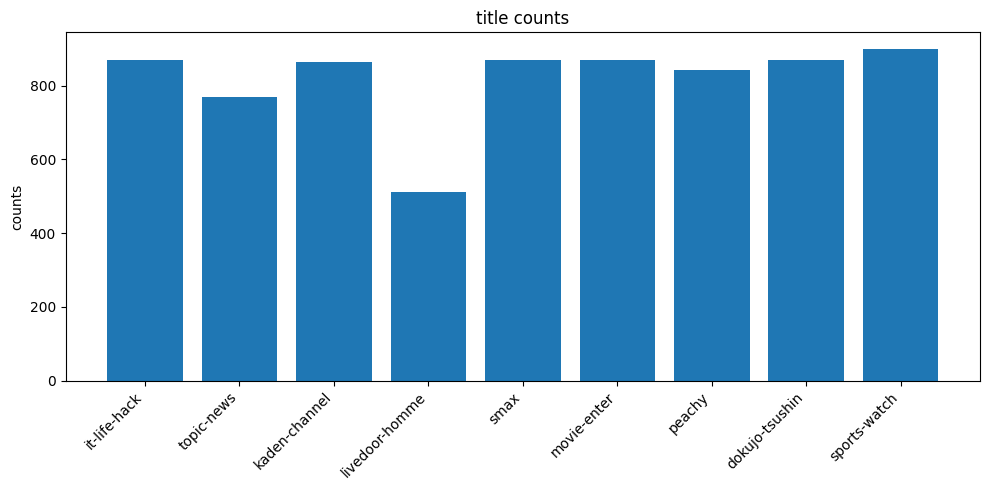

In [63]:
label_counts = Counter([label for _, label in text_label_data])

# dirs（カテゴリ名）の順に並べる
categories = [dirs[i] for i in range(len(dirs))]
counts = [label_counts[i] for i in range(len(dirs))]

plt.figure(figsize=(10, 5))
plt.bar(categories, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("counts")
plt.title("title counts")
plt.tight_layout()
plt.savefig("category_distribution.png", dpi=150)
plt.show()

In [64]:
# データ分割と保存
news_train, news_test = train_test_split(text_label_data, shuffle=True)
news_path = "/content/drive/My Drive/BERT/"

with open(news_path+"news_train.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerows(news_train)

with open(news_path+"news_test.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerows(news_test)

In [65]:

# model, Tokenizerの読み込み
sc_model = BertForSequenceClassification.from_pretrained("cl-tohoku/bert-base-japanese-whole-word-masking", num_labels=9)
sc_model.cuda()
tokenizer = BertJapaneseTokenizer.from_pretrained("cl-tohoku/bert-base-japanese-whole-word-masking")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-whole-word-masking
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missi

In [66]:
# 文章のトーク数の確認

def tokenize_for_check(batch):
    return tokenizer(batch["text"])

news_path = "/content/drive/My Drive/BERT/"

train_data = load_dataset("csv", data_files=news_path+"news_train.csv", column_names=["text", "label"], split="train")
train_data_checked = train_data.map(tokenize_for_check, batched=True, batch_size=len(train_data))


token_lengths = [len(ids) for ids in train_data_checked["input_ids"]]


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/5525 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (942 > 512). Running this sequence through the model will result in indexing errors


In [67]:
print("最大トークン数:", max(token_lengths))
print("平均のトークン数:", round(np.mean(token_lengths)))
print("中央値:", np.median(token_lengths))
print("95%の文章が収まる長さ   :", np.percentile(token_lengths, 95))

最大トークン数: 6672
平均のトークン数: 743
中央値: 620.0
95%の文章が収まる長さ   : 1518.4000000000005


/tmp/ipykernel_386/3883810410.py:9: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_386/3883810410.py:9: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_386/3883810410.py:9: UserWarning: Glyph 12475 (\N{KATAKANA LETTER SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_386/3883810410.py:9: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_386/3883810410.py:9: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_386/3883810410.py:9: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_386/3883810410.py:9: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layo

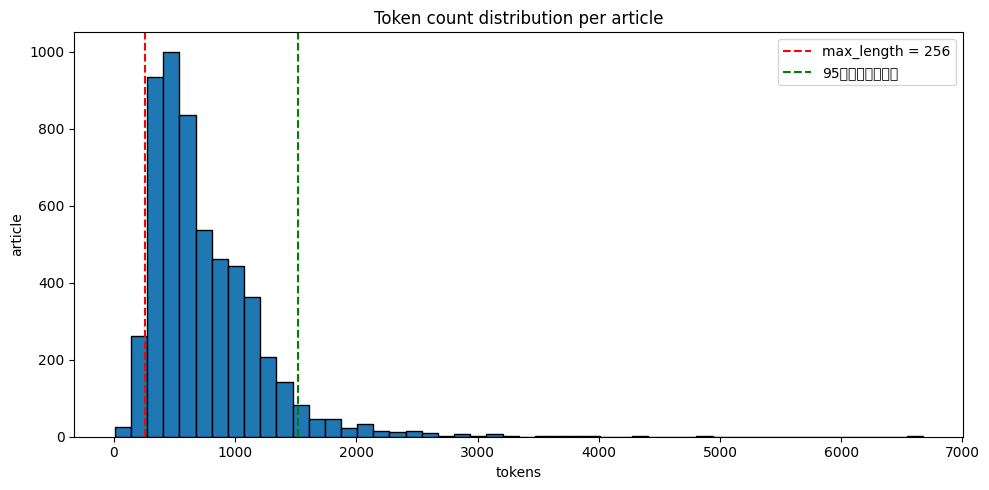

In [68]:
plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=50, edgecolor="black")
plt.axvline(256, color="red", linestyle="--", label="max_length = 256")
plt.axvline(np.percentile(token_lengths, 95), color="green", linestyle="--", label="95パーセンタイル")
plt.xlabel("tokens")
plt.ylabel("article")
plt.title("Token count distribution per article")# 記事ごとのトークン数分布
plt.legend()
plt.tight_layout()
plt.savefig("token_length_distribution.png", dpi=150)
plt.show()

In [69]:
# データの読み込み

def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True, max_length=256)


train_data = train_data.map(tokenize, batched=True, batch_size=len(train_data))
train_data.set_format("torch", columns=["input_ids", "label"])

test_data = load_dataset("csv", data_files=news_path+"news_test.csv", column_names=["text", "label"], split="train")
test_data = test_data.map(tokenize, batched=True, batch_size=len(test_data))
test_data.set_format("torch", columns=["input_ids", "label"])

Map:   0%|          | 0/5525 [00:00<?, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1842 [00:00<?, ? examples/s]

In [70]:

# 評価用の関数の設定

def compute_metrics(result):
    labels = result.label_ids #正解ラベル
    preds = result.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
    }

In [71]:

# ハイパーパラメーターの設定
training_args = TrainingArguments(
    output_dir = "./results",
    num_train_epochs = 2,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 32,
    warmup_steps = 500,
    weight_decay = 0.01,
    logging_dir = "./logs",
    eval_strategy = "steps",
    eval_steps = 100,
    logging_steps = 100,
)

trainer = Trainer(
    model = sc_model,
    args = training_args,
    compute_metrics = compute_metrics,
    train_dataset = train_data,
    eval_dataset = test_data
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [72]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy
100,2.074364,1.702766,0.533659
200,1.239799,0.802394,0.776873
300,0.727739,0.591717,0.824647
400,0.534628,0.534580,0.833876
500,0.604941,0.645320,0.821390
600,0.502945,0.512045,0.837676
700,0.461745,0.516737,0.864278
800,0.312701,0.422070,0.887622
900,0.297886,0.404594,0.889794
1000,0.230170,0.316006,0.915852


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1382, training_loss=0.5573938807254245, metrics={'train_runtime': 1041.0908, 'train_samples_per_second': 10.614, 'train_steps_per_second': 1.327, 'total_flos': 1453779945446400.0, 'train_loss': 0.5573938807254245, 'epoch': 2.0})

In [73]:
# モデル評価
trainer.evaluate()

Training Loss,Validation Loss,Step,Accuracy
0.118783,0.327074,1382,0.926710


{'eval_loss': 0.32707446813583374, 'eval_accuracy': 0.9267100977198697}

In [74]:
predictions = trainer.predict(test_data)
y_pred = predictions.predictions.argmax(axis=1)

In [75]:
y_true = np.array(test_data["label"])

In [76]:
wrong_idx = np.where(y_pred != y_true)[0]

In [77]:
raw_test_data = test_data.with_format(None)

In [78]:
for i in wrong_idx[:10]:
    idx = int(i)

    print("="*80)
    print(f"【インデックス: {idx}】")
    print("ニュース本文:")

    print(raw_test_data["text"][idx][:300])

    print("\n正解ラベル:")
    print(dirs[int(y_true[idx])])

    print("\n予測ラベル:")
    print(dirs[int(y_pred[idx])])

【インデックス: 16】
ニュース本文:
女探偵としてオトコとオンナ、人と人、さらにはお金と人など、多くの現場に立ち会ってきた大徳直美さん。修羅場から感動の場面に至るまで、最前線で見てきた大徳さんに、実際のエピソードを元に、女探偵としての目線から語られる、さまざまな形のオトコとオンナの事情を聞いた。——探偵をされていますが、大徳さんのところに来る依頼のうちメインとなるものはどのような案件ですか？大徳直美（以下、大徳）：やはり、全体の約7割が浮気調査ですね。依頼者のうち、6割が女性、4割が男性です。ここ最近では男性の割合がとても増えてきている傾向にありますね。——みなさん、どのぐらいの確証を持って依頼に来られるのですか？大徳：ほとんどの

正解ラベル:
livedoor-homme

予測ラベル:
dokujo-tsushin
【インデックス: 26】
ニュース本文:
人気キャラクターが公式ツイッターアカウントを持つことは、いまや当然。人気アニメ「とっとこハム太郎」もその一つだ。かわいらしいキャラクターで人気のハム太郎だが、そのツイッターがなかなか興味深い。ファンからの質問やツイートにもよく返事をしているハム太郎。「弱肉強食のピラミッドの最下位にはプランクトンや君たち小動物や草食動物がいる。上にはライオンやチータの肉食獣。そのまた上には何がいると思うかい？‥人間さ」というハムスターには少し意地悪なツイートにハム太郎は「頂点が人間と断言するのはあまりに浅はかなのだ。生かされている事に感謝する考え方はどうなのだ？」と答えている。え？あのハム太郎が？と思ってしまう

正解ラベル:
kaden-channel

予測ラベル:
dokujo-tsushin
【インデックス: 28】
ニュース本文:
ご近所お願い解決アプリと呼ばれる「WishScope」を展開しているザワット株式会社がおもしろいイベントを企画している。７月１５日に開催されるスマートフォン開発者向けのハッカソンイベント「第1回ハッカー道場」だ。このイベントは１日かけて行われ「座学」「実践」「演武」の３つのパートに分かれている。まず、ザワット株式会社をはじめ、イベントに賛同している株式会社エヌプラス及び株式会社VOYAGE GROUPが座学のパートで講義を行い、その後参加者は５時間のハッカソンに挑戦する。そして最後に

In [79]:
news_path = "/content/drive/My Drive/BERT/"

sc_model.save_pretrained(news_path)
tokenizer.save_pretrained(news_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/My Drive/BERT/tokenizer_config.json',
 '/content/drive/My Drive/BERT/vocab.txt',
 '/content/drive/My Drive/BERT/added_tokens.json')

In [80]:
loaded_model = BertForSequenceClassification.from_pretrained(news_path)
loaded_model.cuda()
loaded_tokenizer = BertJapaneseTokenizer.from_pretrained(news_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 日本語ニューズの分類

In [81]:
# 読み込んだモデルを使ってニュースの分類
# 分類したいニュースの読み込み

category = "movie-enter"
sample_path = "/content/drive/My Drive/BERT/text/"
files = glob.glob(sample_path + category + "/*.txt")
file = files[42] #適当に選定

dir_files = os.listdir(path=sample_path)
dirs = [f for f in dir_files if os.path.isdir(os.path.join(sample_path, f))]


# 前処理
with open(file, "r") as f:
    sample_text = f.readlines()[3:]
    sample_text = "".join(sample_text)
    sample_text = sample_text.translate(str.maketrans({"\n":"", "\t":"", "\r":"", "\u3000":""}))

print(sample_text)

ＳＦ小説の巨匠ロバート・Ａ・ハインラインの傑作『宇宙の戦士』を映画化し、巨大昆虫と戦う兵士たちの凄まじい生死をかけた戦いを描いた『スターシップ・トゥルーパーズ』シリーズ。これまで、シリーズ作品が第三作まで製作され、クエンティン・タランティーノを始めとした世界中のファンから熱烈な支持を受けている。この人気シリーズの最新作『スターシップ・トゥルーパーズ：インベイジョン』が、誕生15周年を記念し日本から世界に向けて発信される。これまでに予告編や場面写真が公開されており、第一作からの主人公、ジョニー・リコが“将軍”として登場することや、女性パイロットのカルメン、サイキックの独善主義者カールといったおなじみのキャラクターの再結集、シリーズを通して注目の的であったパワードスーツ“マローダー”が遂に大活躍することなどが判明しており、ファンの期待は高まるばかり。そんな『スターシップ・トゥルーパーズ』ファンの胸をさらに熱くさせるキャンペーンがはじまった。その名も“『スターシップ・トゥルーパーズ インベイジョン』バグ撲滅Twitterキャンペーン”。 このキャンペーンはシリーズ劇中でおなじみのプロパガンダ映像「地球連邦軍ニュース」をモチーフにしたものだ。劇中の「地球連邦ニュース」では地球人と兵士向けへのプロパガンダ映像の最後に「もっと情報を？」という表示が現れ、クリックすると新しい映像が現れるという演出がある。これにちなみ今回のキャンペーンでは、ハッシュタグ「#StiBugs」をつけてツイートし、そのつぶやきが一定数に達することで、新しい「地球連邦ニュース」映像を公式サイトで閲覧することが可能になるというもの。公式サイトのボタンを押して呟くだけで気軽にトルーパー（兵士）たちの戦いを後押しできる。なお、第一弾ニュース映像は111ツイート集まると視聴することができ、合計3種類の「地球連邦ニュース」が用意されているとのことだ。詳細はキャンペーンサイトで確認できる。さあ、野郎ども、今日は死に日和だ。バグにツイートをくれてやれ！『スターシップ・トルーパーズ：インベイジョン』は7月21日より新宿ピカデリー他 全国ロードショー『スターシップ・トルーパーズ：インベイジョン』 - キャンペーンページ『スターシップ・トルーパーズ：インベイジョン』 - 作品情報【関連記事】・死ぬまで戦え！『スターシップ・ト

In [82]:
# モデル挿入への変換
max_lenght = 512
words = loaded_tokenizer.tokenize(sample_text)
word_ids = loaded_tokenizer.convert_tokens_to_ids(words)
word_tensor = torch.tensor([word_ids[:max_lenght]])

x = word_tensor.cuda()
y = loaded_model(x)
pred = y[0].argmax(-1)
print("result: ", dirs[pred])

result:  movie-enter


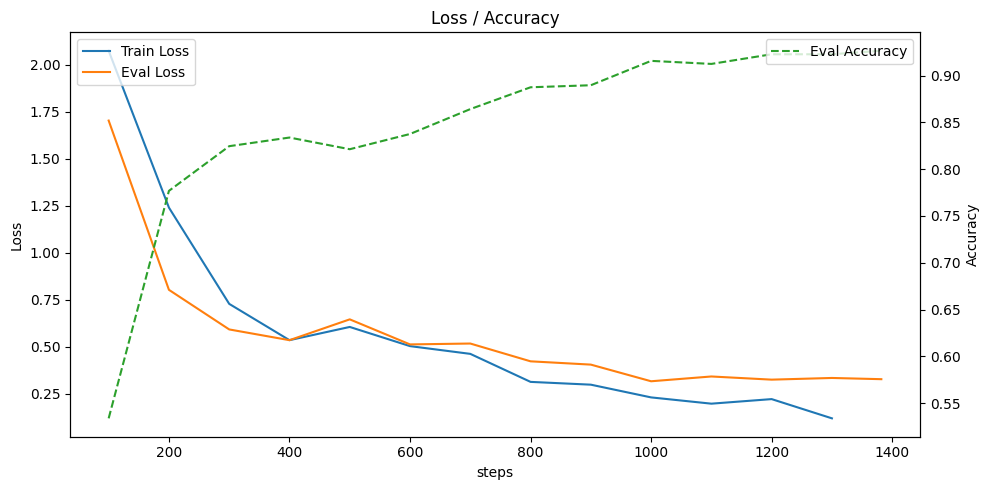

In [84]:
log_history = trainer.state.log_history

# lossとaccuracyをそれぞれ抽出
train_loss = [(x["step"], x["loss"]) for x in log_history if "loss" in x]
eval_acc = [(x["step"], x["eval_accuracy"]) for x in log_history if "eval_accuracy" in x]
eval_loss = [(x["step"], x["eval_loss"]) for x in log_history if "eval_loss" in x]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(*zip(*train_loss), label="Train Loss", color="tab:blue")
ax1.plot(*zip(*eval_loss), label="Eval Loss", color="tab:orange")
ax1.set_xlabel("steps")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(*zip(*eval_acc), label="Eval Accuracy", color="tab:green", linestyle="--")
ax2.set_ylabel("Accuracy")
ax2.legend(loc="upper right")

plt.title("Loss / Accuracy")
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150)
plt.show()


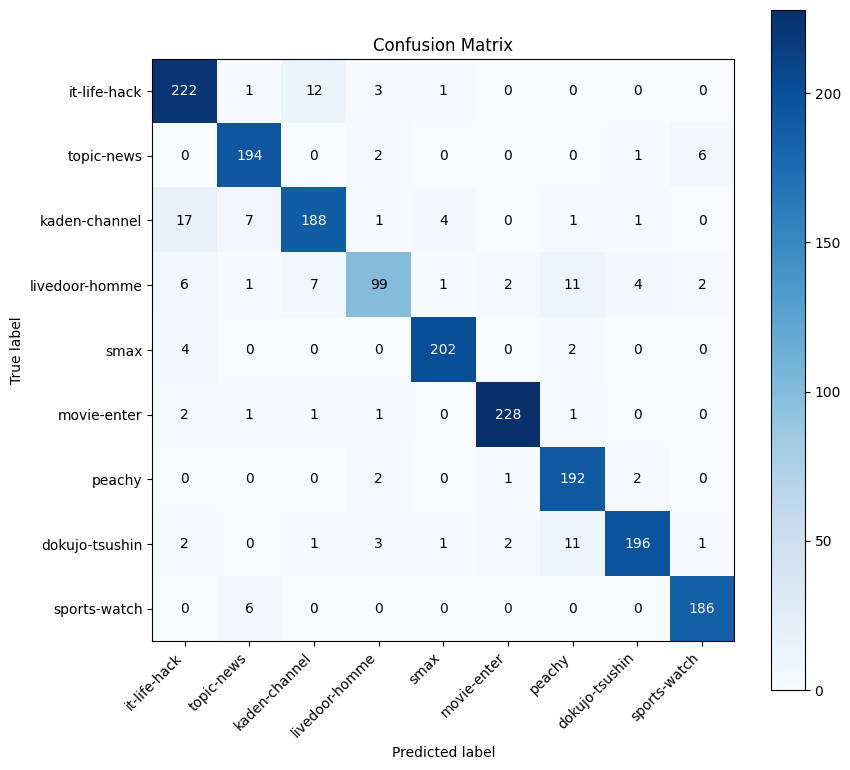

In [86]:
predictions = trainer.predict(test_data)
preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

# 混同行列を計算
cm = confusion_matrix(labels, preds)

# カテゴリ名（dirsの順）
categories = [dirs[i] for i in range(len(dirs))]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(categories)))
ax.set_yticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_yticklabels(categories)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")
# 各セルに数値を表示
for i in range(len(categories)):
    for j in range(len(categories)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()